In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

plt.scatter(X,y)

from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x_train,y_train)
print(reg.coef_)
print(reg.intercept_)

[27.73397487]
-2.4069802954489607


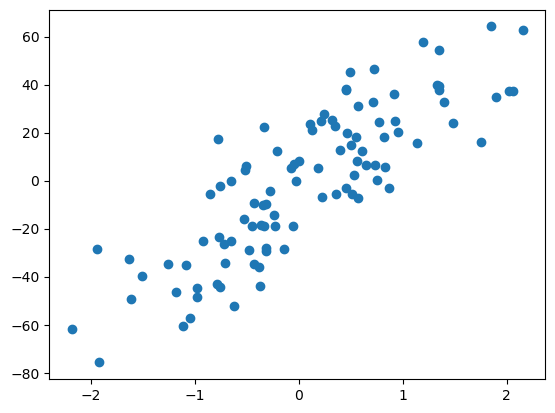

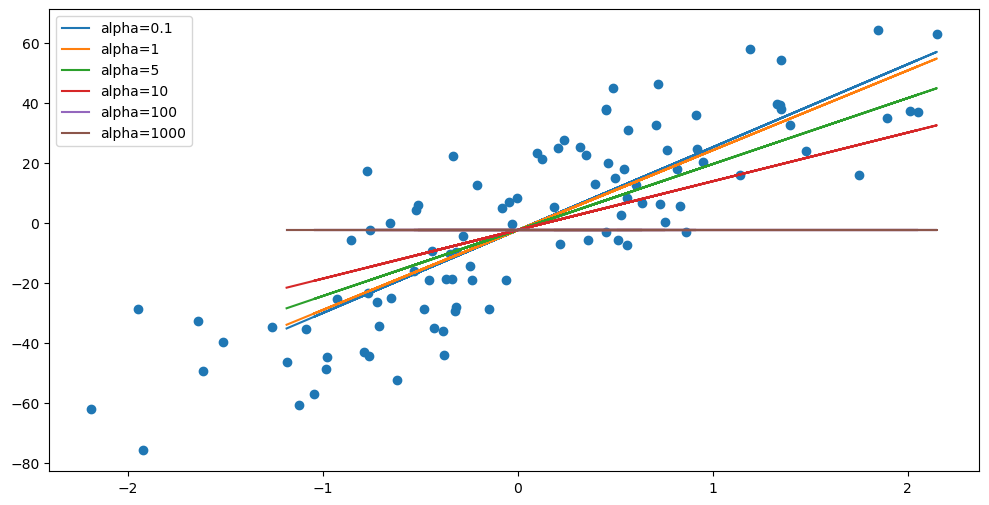

In [4]:
alpha=[0.1,1,5,10,100,1000]
plt.figure(figsize=(12,6))
plt.scatter(X,y)
for i in alpha:
    L=Lasso(alpha=i)
    L.fit(x_train,y_train)
    plt.plot(x_test,L.predict(x_test),label="alpha={}".format(i))
plt.legend()
plt.show()

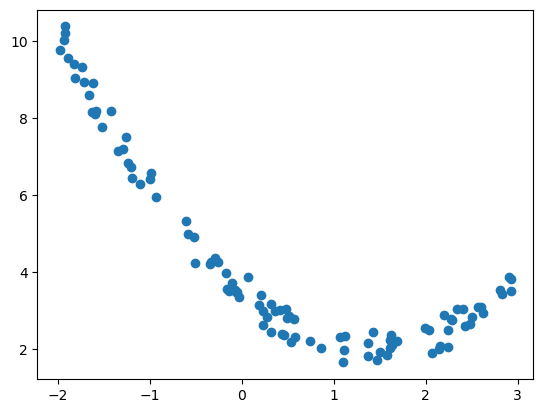

In [5]:
m=100
x1=5*np.random.rand(m,1)-2
x2= 0.7*x1**2 - 2*x1+ 3 +np.random.rand(m,1)
plt.scatter(x1,x2)
plt.show()

C:\Users\heman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.629e+01, tolerance: 6.148e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\heman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.820e+01, tolerance: 6.148e-02
  model = cd_fast.enet_coordinate_descent(
C:\Users\heman\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.554e+02, toleranc

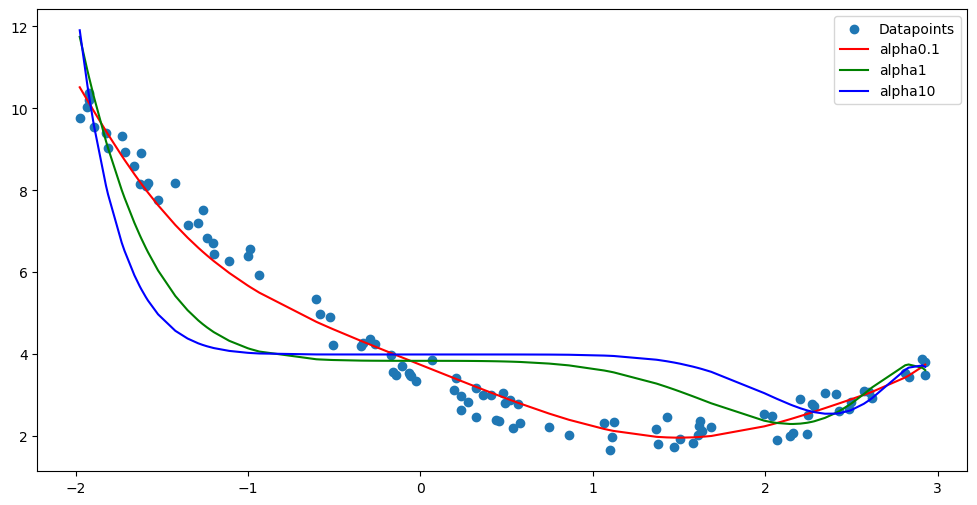

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

def get_pred_lasso(x1,x2,alpha):
    model=Pipeline([
        ("poly",PolynomialFeatures(degree=16)),
        ("r",Lasso(alpha=alpha))
    ])
    model.fit(x1,x2)
    return model.predict(x1)

alphas=[0.1,1,10]
cs=["r","g","b"]

plt.figure(figsize=(12,6))
plt.scatter(x1,x2,label="Datapoints")

for alpha,c in zip(alphas,cs):
    preds=get_pred_lasso(x1,x2,alpha)
    plt.plot(sorted(x1[:,0]),preds[np.argsort(x1[:,0])],c,label="alpha{}".format(alpha))
plt.legend()
plt.show()